# 04a - Entrenamiento de la regresión lineal

En este notebook, se entrena el primer modelo de aprendizaje supervisado considerado en el proyecto: una regresión lineal.

La regresión lineal actúa como modelo interpretable de referencia frente a los modelos no lineales basados en *gradient boosting*. Se entrena una instancia independiente para cada horizonte de predicción considerado en la comparación inicial:

- 1 hora
- 4 horas
- 12 horas
- 24 horas

Nota metodológica: este notebook entrena la versión puntual de la regresión lineal. Las versiones cuantílicas necesarias para CQR se abordarán posteriormente, en la fase de cuantificación de la incertidumbre.

## Objetivos del notebook

1. Cargar los datasets de modelado por horizonte que se han generado en el notebook `02_modeling_dataset_features`
2. Entrenar una regresión lineal para cada horizonte de predicción
3. Aplicar imputación y escalado únicamente dentro del `pipeline` del modelo, ajustados solo con el bloque de entrenamiento
4. Generar predicciones puntuales sobre el conjunto de validación
5. Calcular métricas MAE y RMSE para la comparación inicial de modelos
6. Guardar modelos, predicciones, métricas y coeficientes para su uso en notebooks posteriores

El conjunto de prueba de 2025 no se utiliza en el presente notebook.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models" / "linear_regression"

for directory in [
    REPORTS_TABLES_DIR,
    REPORTS_PREDICTIONS_DIR,
    REPORTS_FIGURES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

HORIZONS = [1, 4, 12, 24]
MAX_EXPECTED_FEATURES = 25

FEATURE_COLUMNS_PATH = DATA_MODELING_DIR / "feature_columns.json"

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Directorio de datasets de modelado: {DATA_MODELING_DIR}")
print(f"Directorio de modelos: {MODELS_DIR}")

Raíz del proyecto: c:\trabajo_github
Directorio de datasets de modelado: c:\trabajo_github\data\modeling
Directorio de modelos: c:\trabajo_github\models\linear_regression


## Carga de las variables predictoras

El notebook `02_modeling_dataset_features` genera un archivo `feature_columns.json` con la lista de las variables predictoras.

Se utiliza la lista específica de cada horizonte (`feature_columns_by_horizon`) porque algunos retardos pueden coincidir exactamente para determinados horizontes. Por ejemplo, en h=24, el valor de la misma hora del día anterior podría coincidir con el valor observado en el origen de predicción.

In [ ]:
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado el archivo data/modeling/feature_columns.json. "
        "Debe ejecutarse primero el notebook 02_modeling_dataset_features."
    )

feature_payload = json.loads(FEATURE_COLUMNS_PATH.read_text(encoding="utf-8"))

feature_columns_by_horizon: Dict[str, List[str]] = feature_payload.get(
    "feature_columns_by_horizon",
    {},
)

default_feature_columns: List[str] = feature_payload.get("feature_columns", [])

if not feature_columns_by_horizon and not default_feature_columns:
    raise ValueError(
        "El archivo feature_columns.json no contiene listas de variables predictoras."
    )

feature_summary_rows = []

for horizon in HORIZONS:
    feature_cols = feature_columns_by_horizon.get(str(horizon), default_feature_columns)

    feature_summary_rows.append(
        {
            "horizon": horizon,
            "n_features": len(feature_cols),
            "features": feature_cols,
        }
    )

    if len(feature_cols) > MAX_EXPECTED_FEATURES:
        raise ValueError(
            f"El horizonte {horizon} contiene {len(feature_cols)} variables. "
            f"Se esperaba un conjunto de como máximo {MAX_EXPECTED_FEATURES}. "
        )

feature_summary_df = pd.DataFrame(feature_summary_rows)
display(feature_summary_df[["horizon", "n_features"]])

,horizon,n_features
0,1,21
1,4,21
2,12,20
3,24,20


## Carga de los datasets de modelado por horizonte

Cada dataset contiene filas de la forma:

$$
X_t \rightarrow y_{t+h}
$$

donde:

- `origin_timestamp` es el instante desde el que se formula la predicción
- `target_timestamp` es el instante objetivo
- `y` es la concentración de O3 que se desea predecir
- Las variables predictoras se han construido con información disponible en `origin_timestamp` o antes, salvo las variables de calendario del objetivo, que se conocen de antemano.

Nota: La partición cronológica ya está asignada en la columna `split`.

In [4]:
def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    """Carga el dataset de modelado correspondiente a un horizonte."""
    file_path = DATA_MODELING_DIR / f"modeling_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. "
            "Debe ejecutarse primero el notebook 02_modeling_dataset_features."
        )

    df = pd.read_parquet(file_path)
    df = df.sort_values("target_timestamp").reset_index(drop=True)

    return df


datasets_by_horizon: Dict[int, pd.DataFrame] = {
    horizon: load_modeling_dataset(horizon)
    for horizon in HORIZONS
}

dataset_overview_rows = []

for horizon, df in datasets_by_horizon.items():
    dataset_overview_rows.append(
        {
            "horizon": horizon,
            "n_rows": len(df),
            "splits": sorted(df["split"].dropna().unique().tolist()),
            "target_min": df["target_timestamp"].min(),
            "target_max": df["target_timestamp"].max(),
            "missing_y": df["y"].isna().sum(),
        }
    )

dataset_overview_df = pd.DataFrame(dataset_overview_rows)
display(dataset_overview_df)

,horizon,n_rows,splits,target_min,target_max,missing_y
0,1,50941,"[calibration, test, train, validation]",2020-01-01 01:00:00,2025-12-31 23:00:00,0
1,4,50938,"[calibration, test, train, validation]",2020-01-01 04:00:00,2025-12-31 23:00:00,0
2,12,50930,"[calibration, test, train, validation]",2020-01-01 12:00:00,2025-12-31 23:00:00,0
3,24,50918,"[calibration, test, train, validation]",2020-01-02 00:00:00,2025-12-31 23:00:00,0


## Preparación del modelo

La regresión lineal de la librería `scikit-learn` no admite valores ausentes en las variables predictoras. Para mantener la política metodológica de no imputar globalmente la serie, esta imputación se realiza dentro del pipeline del modelo:

1. `SimpleImputer(strategy="median")`: sustituye valores ausentes usando medianas aprendidas solamente en el entrenamiento
2. `StandardScaler()`: estandariza las variables utilizando la media y la desviación aprendidas solamente en el entrenamiento
3. `LinearRegression()`: ajusta la relación lineal entre las variables predictoras y la concentración objetivo

Este procedimiento evita la fuga temporal, porque el imputador y el escalador se ajustan exclusivamente con el bloque de entrenamiento.

In [5]:
def build_linear_regression_pipeline() -> Pipeline:
    """Construye el pipeline de la regresión lineal.

    La imputación y el escalado quedan dentro del pipeline para garantizar que
    sus parámetros se estimen únicamente con el conjunto de entrenamiento.
    """
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )


def prepare_split(
    df: pd.DataFrame,
    feature_columns: list[str],
    split_name: str,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Extrae X, y y metadatos de una partición en concreto.

    Se eliminan únicamente las filas sin variable objetivo (`y`), ya que no pueden
    utilizarse ni para ajustar ni para evaluar el modelo. Los valores ausentes en las
    variables predictoras se conservan para que los trate el pipeline.
    """
    split_df = df.loc[df["split"] == split_name].copy()
    split_df = split_df.dropna(subset=["y"]).copy()

    missing_columns = [column for column in feature_columns if column not in split_df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas predictoras en split={split_name}: {missing_columns}")

    X = split_df[feature_columns]
    y = split_df["y"]

    metadata_columns = [
        "horizon",
        "split",
        "origin_timestamp",
        "target_timestamp",
    ]

    metadata = split_df[metadata_columns].copy()

    return X, y, metadata


def compute_point_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """Calcula métricas de predicción puntual."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "mae": mae,
        "rmse": rmse,
    }

## Entrenamiento por horizonte

Se ajusta una instancia independiente de la regresión lineal para cada horizonte. En este notebook no se aplica la técnica de validación cruzada de series temporales con origen de predicción variable de Hyndman porque la regresión lineal estándar no tiene hiperparámetros relevantes que seleccionar.

La validación interna mediante dicha técnica se reservará, pues, para los modelos que sí requieran selección de hiperparámetros, esto es, LightGBM y CatBoost.

In [6]:
models_by_horizon: Dict[int, Pipeline] = {}
metrics_rows: list[dict] = []
prediction_frames: list[pd.DataFrame] = []
coefficient_rows: list[dict] = []
training_summary_rows: list[dict] = []

for horizon, df in datasets_by_horizon.items():
    print("=" * 80)
    print(f"Entrenando la regresión lineal para h={horizon} h")

    feature_columns = feature_columns_by_horizon.get(str(horizon), default_feature_columns)

    X_train, y_train, train_metadata = prepare_split(df, feature_columns, "train")
    X_validation, y_validation, validation_metadata = prepare_split(df, feature_columns, "validation")

    if X_train.empty:
        raise ValueError(f"No hay filas de entrenamiento para h={horizon}.")
    if X_validation.empty:
        raise ValueError(f"No hay filas de validación para h={horizon}.")

    pipeline = build_linear_regression_pipeline()
    pipeline.fit(X_train, y_train)

    models_by_horizon[horizon] = pipeline

    # Predicciones de entrenamiento: se usan solo para el diagnóstico interno.
    y_train_pred = pipeline.predict(X_train)

    # Predicciones de validación: estas sí serán las empleadas en la comparación inicial.
    y_validation_pred = pipeline.predict(X_validation)

    train_metrics = compute_point_metrics(y_train, y_train_pred)
    validation_metrics = compute_point_metrics(y_validation, y_validation_pred)

    metrics_rows.append(
        {
            "model": "linear_regression",
            "horizon": horizon,
            "split": "train",
            "n_observations": len(y_train),
            "mae": train_metrics["mae"],
            "rmse": train_metrics["rmse"],
            "n_negative_predictions": int((y_train_pred < 0).sum()),
        }
    )

    metrics_rows.append(
        {
            "model": "linear_regression",
            "horizon": horizon,
            "split": "validation",
            "n_observations": len(y_validation),
            "mae": validation_metrics["mae"],
            "rmse": validation_metrics["rmse"],
            "n_negative_predictions": int((y_validation_pred < 0).sum()),
        }
    )

    validation_predictions = validation_metadata.copy()
    validation_predictions["model"] = "linear_regression"
    validation_predictions["y_true"] = y_validation.to_numpy()
    validation_predictions["y_pred"] = y_validation_pred
    validation_predictions["residual"] = validation_predictions["y_true"] - validation_predictions["y_pred"]
    validation_predictions["abs_error"] = validation_predictions["residual"].abs()

    prediction_frames.append(validation_predictions)

    # Guardado del modelo de cada horizonte.
    model_path = MODELS_DIR / f"linear_regression_h{horizon:02d}.joblib"
    joblib.dump(pipeline, model_path)

    # Coeficientes de la regresión lineal.
    # Como el modelo se ajusta tras estandarizar las variables, estos coeficientes
    # deben interpretarse como coeficientes sobre variables estandarizadas.
    model = pipeline.named_steps["model"]

    for feature, coefficient in zip(feature_columns, model.coef_):
        coefficient_rows.append(
            {
                "model": "linear_regression",
                "horizon": horizon,
                "feature": feature,
                "coefficient_standardized": coefficient,
                "abs_coefficient_standardized": abs(coefficient),
            }
        )

    training_summary_rows.append(
        {
            "horizon": horizon,
            "n_features": len(feature_columns),
            "n_train": len(y_train),
            "n_validation": len(y_validation),
            "model_path": str(model_path.relative_to(PROJECT_ROOT)),
            "train_target_min": train_metadata["target_timestamp"].min(),
            "train_target_max": train_metadata["target_timestamp"].max(),
            "validation_target_min": validation_metadata["target_timestamp"].min(),
            "validation_target_max": validation_metadata["target_timestamp"].max(),
        }
    )

    print(
        f"h={horizon:02d} | "
        f"MAE validación={validation_metrics['mae']:.3f} | "
        f"RMSE validación={validation_metrics['rmse']:.3f}"
    )

Entrenando la regresión lineal para h=1 h
h=01 | MAE validación=6.624 | RMSE validación=9.043
Entrenando la regresión lineal para h=4 h
h=04 | MAE validación=12.628 | RMSE validación=15.950
Entrenando la regresión lineal para h=12 h
h=12 | MAE validación=14.127 | RMSE validación=17.650
Entrenando la regresión lineal para h=24 h
h=24 | MAE validación=14.526 | RMSE validación=18.052


## Resultados de la predicción puntual

Las métricas de entrenamiento se muestran solamente a modo de diagnóstico. La comparación inicial entre modelos se realizará sobre el conjunto de validación, tal como se definió en la metodología.

Como se establece en la metodología, el conjunto de prueba no se utilizará.

In [7]:
metrics_df = pd.DataFrame(metrics_rows)
training_summary_df = pd.DataFrame(training_summary_rows)
coefficients_df = pd.DataFrame(coefficient_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df)
display(training_summary_df)

validation_metrics_df = metrics_df.loc[metrics_df["split"] == "validation"].copy()
display(validation_metrics_df)

,model,horizon,split,n_observations,mae,rmse,n_negative_predictions
0,linear_regression,1,train,25516,6.437367,8.726686,61
1,linear_regression,1,validation,8437,6.624478,9.043443,20
2,linear_regression,4,train,25513,12.248207,15.585504,114
3,linear_regression,4,validation,8437,12.628281,15.950134,34
4,linear_regression,12,train,25505,13.646010,17.187218,19
5,linear_regression,12,validation,8437,14.127141,17.649996,6
6,linear_regression,24,train,25493,13.807567,17.346621,0
7,linear_regression,24,validation,8437,14.525940,18.052266,0


,horizon,n_features,n_train,n_validation,model_path,train_target_min,train_target_max,validation_target_min,validation_target_max
0,1,21,25516,8437,models\linear_regression\linear_regression_h01...,2020-01-01 01:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
1,4,21,25513,8437,models\linear_regression\linear_regression_h04...,2020-01-01 04:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
2,12,20,25505,8437,models\linear_regression\linear_regression_h12...,2020-01-01 12:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
3,24,20,25493,8437,models\linear_regression\linear_regression_h24...,2020-01-02 00:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00


,model,horizon,split,n_observations,mae,rmse,n_negative_predictions
1,linear_regression,1,validation,8437,6.624478,9.043443,20
3,linear_regression,4,validation,8437,12.628281,15.950134,34
5,linear_regression,12,validation,8437,14.127141,17.649996,6
7,linear_regression,24,validation,8437,14.525940,18.052266,0


## Guardado de los modelos, las predicciones y las tablas

Se guardan:

- Los modelos ajustados por horizonte
- Las predicciones puntuales de validación
- Las métricas MAE/RMSE
- Los coeficientes estandarizados de la regresión lineal
- EL resumen del entrenamiento

Las predicciones de validación se almacenan en archivos separados por horizonte para facilitar la comparación posterior con el modelo base, LightGBM y CatBoost.

In [8]:
# Predicciones por horizonte.
for horizon in HORIZONS:
    horizon_predictions = predictions_df.loc[predictions_df["horizon"] == horizon].copy()

    predictions_path = REPORTS_PREDICTIONS_DIR / f"linear_regression_h{horizon:02d}.parquet"
    horizon_predictions.to_parquet(predictions_path, index=False)

    print(f"Guardado: {predictions_path} ({len(horizon_predictions):,} filas)")

# Tablas agregadas.
metrics_path = REPORTS_TABLES_DIR / "linear_regression_point_metrics.csv"
training_summary_path = REPORTS_TABLES_DIR / "linear_regression_training_summary.csv"
coefficients_path = REPORTS_TABLES_DIR / "linear_regression_coefficients.csv"

metrics_df.to_csv(metrics_path, index=False)
training_summary_df.to_csv(training_summary_path, index=False)
coefficients_df.to_csv(coefficients_path, index=False)

print(f"Guardado: {metrics_path}")
print(f"Guardado: {training_summary_path}")
print(f"Guardado: {coefficients_path}")

Guardado: c:\trabajo_github\reports\predictions\linear_regression_h01.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\linear_regression_h04.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\linear_regression_h12.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\linear_regression_h24.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\tables\linear_regression_point_metrics.csv
Guardado: c:\trabajo_github\reports\tables\linear_regression_training_summary.csv
Guardado: c:\trabajo_github\reports\tables\linear_regression_coefficients.csv


## Visualización de las métricas para el conjunto de validación

Esta figura resume el error puntual de la regresión lineal en el conjunto de validación. Se utiliza únicamente como diagnóstico del modelo y como preparación para la comparación conjunta posterior.

Figura guardada en: c:\trabajo_github\reports\figures\fig_linear_regression_point_metrics_validation.png


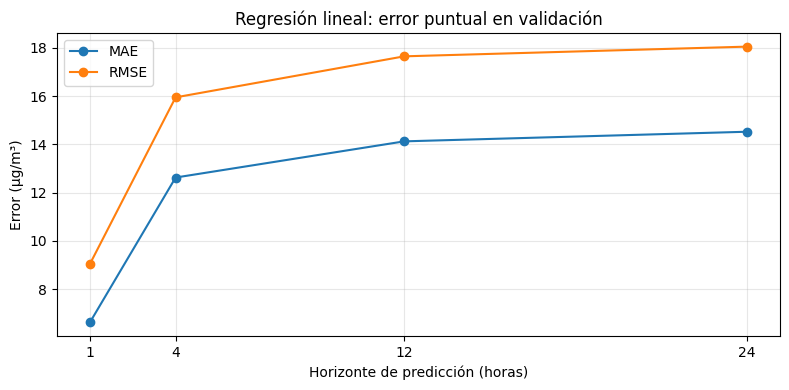

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

validation_metrics_sorted = validation_metrics_df.sort_values("horizon")

ax.plot(
    validation_metrics_sorted["horizon"],
    validation_metrics_sorted["mae"],
    marker="o",
    label="MAE",
)

ax.plot(
    validation_metrics_sorted["horizon"],
    validation_metrics_sorted["rmse"],
    marker="o",
    label="RMSE",
)

ax.set_title("Regresión lineal: error puntual en validación")
ax.set_xlabel("Horizonte de predicción (horas)")
ax.set_ylabel("Error (µg/m³)")
ax.set_xticks(HORIZONS)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / "fig_linear_regression_point_metrics_validation.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Inspección visual sobre un tramo de carácter continuo

Para evitar gráficos con saltos debidos a valores ausentes, se selecciona automáticamente un bloque continuo de horas evaluables en validación. Esta figura es solo ilustrativa: como es lógico, las métricas se calcularán sobre todas las observaciones evaluables del conjunto de validación.

Tramo seleccionado: 2024-01-16 14:00:00 → 2024-01-30 13:00:00 (336 horas)
Figura guardada en: c:\trabajo_github\reports\figures\fig_linear_regression_validation_zoom_h24.png


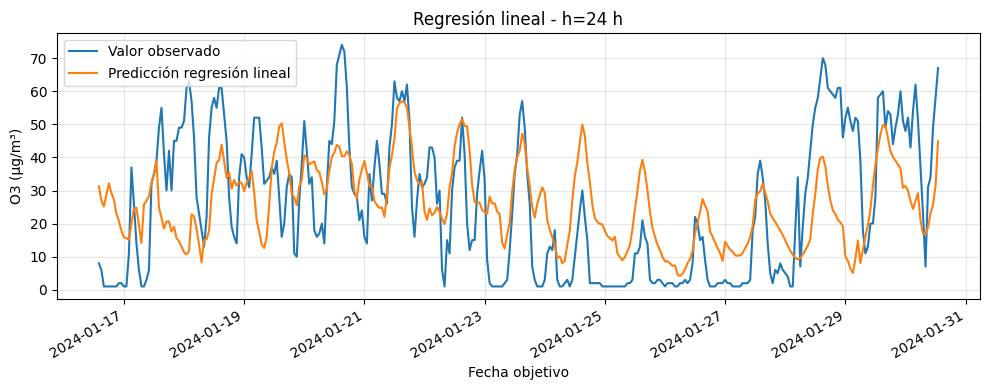

In [10]:
def select_continuous_evaluable_block(
    predictions: pd.DataFrame,
    horizon: int,
    n_hours: int,
) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de horas evaluables.

    Se consideran evaluables las filas que contienen tanto un valor real como una predicción.
    """
    example = predictions.loc[predictions["horizon"] == horizon].copy()
    example = example.sort_values("target_timestamp")
    example = example.dropna(subset=["y_true", "y_pred"]).copy()

    if example.empty:
        raise ValueError(f"No hay observaciones evaluables para h={horizon}.")

    example["delta_h"] = (
        example["target_timestamp"].diff() / pd.Timedelta(hours=1)
    )

    example["continuous_block"] = (
        example["delta_h"].isna() | (example["delta_h"] != 1)
    ).cumsum()

    block_summary = (
        example
        .groupby("continuous_block")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidate_blocks = block_summary.loc[block_summary["n_hours"] >= n_hours]

    if candidate_blocks.empty:
        selected_block_id = block_summary.sort_values("n_hours", ascending=False).iloc[0]["continuous_block"]
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        selected_block_id = candidate_blocks.sort_values("start").iloc[0]["continuous_block"]

    selected = example.loc[example["continuous_block"] == selected_block_id].copy()
    selected = selected.head(n_hours)

    return selected


EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 14 * 24

example_zoom = select_continuous_evaluable_block(
    predictions_df,
    horizon=EXAMPLE_HORIZON,
    n_hours=EXAMPLE_HOURS,
)

print(
    "Tramo seleccionado:",
    example_zoom["target_timestamp"].min(),
    "→",
    example_zoom["target_timestamp"].max(),
    f"({len(example_zoom)} horas)"
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_true"],
    label="Valor observado",
)

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_pred"],
    label="Predicción regresión lineal",
)

ax.set_title(f"Regresión lineal - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / f"fig_linear_regression_validation_zoom_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Coeficientes de la regresión lineal

La tabla de coeficientes se guarda para la futura fase de explicabilidad. Como las variables se estandarizan dentro del `pipeline`, los coeficientes permiten comparar la contribución relativa de las variables medidas en escalas distintas.

Esta interpretación debe realizarse, en todo caso, con cautela, especialmente cuando existen variables correlacionadas entre sí, como retardos y ventanas móviles.

,model,horizon,feature,coefficient_standardized,abs_coefficient_standardized
0,linear_regression,1,o3_at_origin,25.761988,25.761988
1,linear_regression,1,o3_lag_1h,-4.901706,4.901706
2,linear_regression,1,o3_roll_mean_24h,3.587181,3.587181
3,linear_regression,1,o3_roll_mean_6h,-1.988824,1.988824
4,linear_regression,1,target_hour_cos,-1.265460,1.265460
5,linear_regression,1,o3_lag_12h,-1.078376,1.078376
6,linear_regression,1,target_is_weekend,0.802891,0.802891
7,linear_regression,1,o3_target_lag_48h,0.760735,0.760735
8,linear_regression,1,o3_prev_day_same_hour,0.750043,0.750043
9,linear_regression,1,target_hour_sin,-0.590421,0.590421


Figura guardada en: c:\trabajo_github\reports\figures\fig_linear_regression_coefficients_h24.png


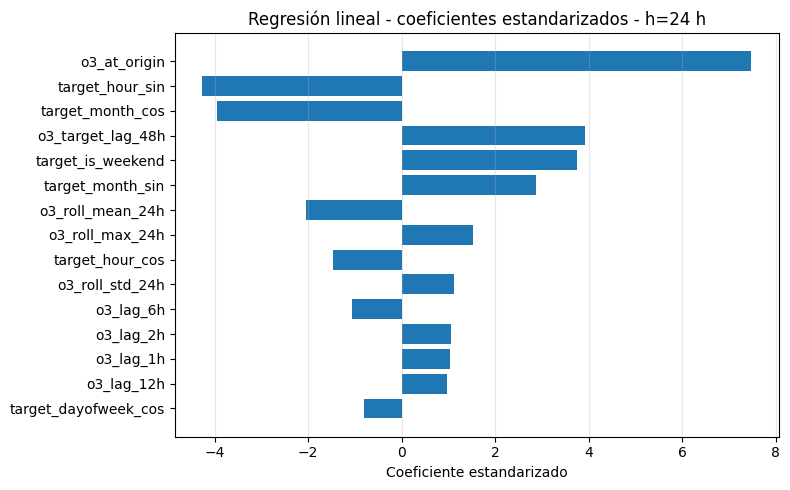

In [11]:
# Se muestran los coeficientes de mayor magnitud para cada horizonte.
top_coefficients = (
    coefficients_df
    .sort_values(["horizon", "abs_coefficient_standardized"], ascending=[True, False])
    .groupby("horizon")
    .head(10)
    .reset_index(drop=True)
)

display(top_coefficients)

# Se dibuja la figura de coeficientes para el horizonte de ejemplo.
coef_example = (
    coefficients_df.loc[coefficients_df["horizon"] == EXAMPLE_HORIZON]
    .sort_values("abs_coefficient_standardized", ascending=False)
    .head(15)
    .sort_values("abs_coefficient_standardized", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    coef_example["feature"],
    coef_example["coefficient_standardized"],
)

ax.set_title(f"Regresión lineal - coeficientes estandarizados - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Coeficiente estandarizado")
ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / f"fig_linear_regression_coefficients_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Comprobaciones finales

Las comprobaciones finales nos permiten verificar que:

- Se han generado los modelos para los cuatro horizontes
- Se han guardado las predicciones de validación
- No se ha utilizado el conjunto de prueba
- Las predicciones no contienen valores ausentes
- Las variables se mantienen dentro del conjunto definido en el notebook de ingeniería de características

In [12]:
expected_model_files = [
    MODELS_DIR / f"linear_regression_h{horizon:02d}.joblib"
    for horizon in HORIZONS
]

expected_prediction_files = [
    REPORTS_PREDICTIONS_DIR / f"linear_regression_h{horizon:02d}.parquet"
    for horizon in HORIZONS
]

expected_table_files = [
    metrics_path,
    training_summary_path,
    coefficients_path,
]

missing_files = [
    path for path in expected_model_files + expected_prediction_files + expected_table_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(f"No se han generado los siguientes archivos esperados: {missing_files}")

if (predictions_df["split"] == "test").any():
    raise AssertionError("Se han generado predicciones sobre el conjunto de prueba, lo cual no corresponde en esta fase.")

if predictions_df["y_pred"].isna().any():
    raise AssertionError("Existen predicciones ausentes.")

for horizon in HORIZONS:
    n_features = len(feature_columns_by_horizon.get(str(horizon), default_feature_columns))
    if n_features > MAX_EXPECTED_FEATURES:
        raise AssertionError(f"El horizonte {horizon} supera el número máximo de variables previsto.")

final_check_df = pd.DataFrame(
    {
        "check": [
            "modelos_guardados",
            "predicciones_guardadas",
            "tablas_guardadas",
            "sin_test",
            "sin_predicciones_nan",
            "feature_set_compacto",
        ],
        "status": ["ok", "ok", "ok", "ok", "ok", "ok"],
    }
)

display(final_check_df)

print("Comprobaciones finales superadas. La regresión lineal puntual está lista para la comparación inicial.")

,check,status
0,modelos_guardados,ok
1,predicciones_guardadas,ok
2,tablas_guardadas,ok
3,sin_test,ok
4,sin_predicciones_nan,ok
5,feature_set_compacto,ok


Comprobaciones finales superadas. La regresión lineal puntual está lista para la comparación inicial.
